# AI for Communication and Marketing  
## Lab Exam – Part 2

**Academic Year:** 2025/2026  
**Course:** B.Sc. in Artificial Intelligence  
**Student:** Marta Paniconi  
**Student ID:** 535358

---------------

## Business Scenario

You are a Data Scientist for a leading E-commerce platform. The Marketing department is concerned
about customer retention. You have been provided with a dataset named **"data.csv"** containing
customer profiles, satisfaction scores, and transaction summaries.

---------------

# Task A — Data Audit & Quality

This section performs the initial data quality assessment for the customer churn dataset.

Before any exploratory analysis or modeling, the dataset must be checked for structure, missing values, data types, duplicates, inconsistencies and potential outliers.  
The goal is to create a clean and machine-learning-ready dataframe while documenting every cleaning decision.

## A.1 Load libraries and dataset

We begin by loading the required libraries and importing the dataset.  
This first inspection checks the dataset size, column structure, data types and basic descriptive statistics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# The original dataset is provided as **data.xlsx**. It has been exported to CSV format for processing with pandas.
df = pd.read_csv('data.csv', sep=',')

display(df.shape)
display(df.head())
display(df.columns.tolist())
display(df.dtypes)
display(df.describe(include='all').T)

(5630, 20)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


['CustomerID',
 'Churn',
 'Tenure',
 'PreferredLoginDevice',
 'CityTier',
 'WarehouseToHome',
 'PreferredPaymentMode',
 'Gender',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'PreferedOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

CustomerID                     float64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5628.0,NaN,NaN,NaN,52814.549041,1624.890759,50001.0,51407.75,52814.5,54221.25,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5366.0,NaN,NaN,NaN,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
PreferredLoginDevice,5630,4,Mobile Phone,2763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,NaN,NaN,NaN,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5628,2,Male,3383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5375.0,NaN,NaN,NaN,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


- The dataset contains **5,630 customers and 20 columns**, with `Churn` as the target variable for the prediction task.
- `CustomerID` is only an identifier and should not be used as a predictive feature during modeling.
- The dataset includes both numerical variables, such as `Tenure`, `WarehouseToHome`, `OrderCount`, `DaySinceLastOrder` and `CashbackAmount`, and categorical variables, such as `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat` and `MaritalStatus`.
- Several columns contain missing values, especially behavioral variables such as `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderCount`, `CouponUsed` and `DaySinceLastOrder`; these will be analyzed and handled in the next steps.
- Some numerical variables show potentially extreme values, especially `CashbackAmount`, which will require a more detailed consistency and outlier check before modeling.

## A.2 Data type audit

This step separates numerical and categorical variables and inspects the observed categories before any cleaning or encoding.

The goal is only to understand the structure of the dataset and identify which variables will require later preprocessing.

In [12]:
# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Compact summary of variable types
type_summary = pd.DataFrame({
    "Variable Type": ["Numerical", "Categorical"],
    "Number of Columns": [len(numeric_cols), len(cat_cols)],
    "Columns": [numeric_cols, cat_cols]
})

display(type_summary)

,Variable Type,Number of Columns,Columns
0,Numerical,15,"[CustomerID, Churn, Tenure, CityTier, Warehous..."
1,Categorical,5,"[PreferredLoginDevice, PreferredPaymentMode, G..."


In [14]:
# Show categorical variables and number of unique values
categorical_summary = pd.DataFrame({
    "Categorical Column": cat_cols,
    "Unique Values": [df[col].nunique(dropna=True) for col in cat_cols]
})

display(categorical_summary)

,Categorical Column,Unique Values
0,PreferredLoginDevice,4
1,PreferredPaymentMode,7
2,Gender,2
3,PreferedOrderCat,6
4,MaritalStatus,4


In [15]:
# Display value counts for each categorical column
for col in cat_cols:
    print(f"\n{col} — value counts")
    display(
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="Count")
    )


PreferredLoginDevice — value counts


,PreferredLoginDevice,Count
0,Mobile Phone,2763
1,Computer,1632
2,Phone,1230
3,N.A.,5



PreferredPaymentMode — value counts


,PreferredPaymentMode,Count
0,Debit Card,2314
1,Credit Card,1501
2,E wallet,614
3,UPI,414
4,COD,365
5,CC,273
6,Cash on Delivery,149



Gender — value counts


,Gender,Count
0,Male,3383
1,Female,2245
2,NaN,2



PreferedOrderCat — value counts


,PreferedOrderCat,Count
0,Laptop & Accessory,2050
1,Mobile Phone,1271
2,Fashion,826
3,Mobile,809
4,Grocery,410
5,Others,264



MaritalStatus — value counts


,MaritalStatus,Count
0,Married,2984
1,Single,1795
2,Divorced,848
3,Widow,3


**Data type audit — interpretation**

- The dataset contains **15 numerical columns** and **5 categorical columns**.
- The categorical variables are `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat` and `MaritalStatus`; these will require encoding before modeling.
- The category counts show some labels that should be standardized later, especially in `PreferredLoginDevice` and `PreferredPaymentMode`, where similar meanings may be written with different labels.
- No transformations are applied in this section; the goal is only to inspect variable types and category distributions before cleaning.

### A.3 Missing values audit

Quantifying missing values determines whether imputation or row removal
is more appropriate.

,Missing_Count,Missing_Pct
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46
CustomerID,2,0.04
Gender,2,0.04


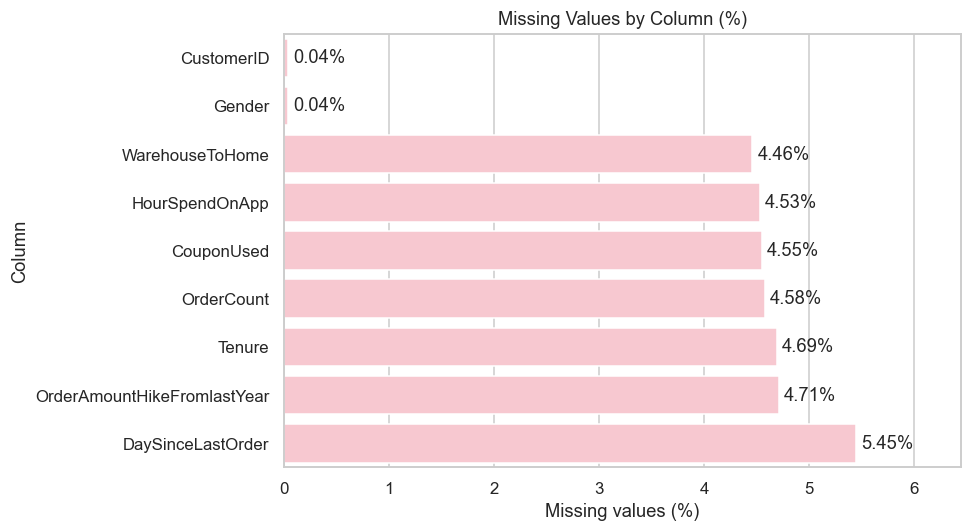

In [16]:
# Calculate missing values by column
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Pct": missing_pct
})

# Keep only columns with missing values and sort from highest to lowest
missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Pct", ascending=False)
)

display(missing_summary)

# Create a clearer table for plotting
missing_plot = (
    missing_summary
    .reset_index()
    .rename(columns={"index": "Column"})
    .sort_values("Missing_Pct", ascending=True)
)

# Plot missing values as horizontal bar chart
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=missing_plot,
    x="Missing_Pct",
    y="Column",
    color="pink"
)

plt.title("Missing Values by Column (%)")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")

# Add percentage labels at the end of each bar
for i, value in enumerate(missing_plot["Missing_Pct"]):
    ax.text(
        value + 0.05,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.xlim(0, missing_plot["Missing_Pct"].max() + 1)
plt.tight_layout()
plt.show()

- Missing values are concentrated in a small group of variables, with the highest missingness in `DaySinceLastOrder` (**5.45%**), followed by `OrderAmountHikeFromlastYear` (**4.71%**) and `Tenure` (**4.69%**).
- Most missing values concern behavioral variables that are relevant for churn prediction, so they should be imputed rather than removed.
- No column exceeds **6% missingness**, therefore dropping entire columns is not justified.
- `CustomerID` and `Gender` have only **2 missing values** each (**0.04%**). Since `CustomerID` is an identifier, rows without it can be removed; the very small missingness in `Gender` can also be handled during cleaning.
- The cleaning strategy will use median imputation for numerical missing values and minimal row removal only where the missing information is not useful or cannot be reliably imputed.

## A.4 Consistency and outlier audit

This section checks whether numerical variables contain impossible values or extreme observations.

No cleaning is applied at this stage. The goal is to identify which values require treatment in the next cleaning step and which high values should be preserved as valid customer behavior.

In [17]:
# Key numerical variables to audit
audit_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

audit_cols = [col for col in audit_cols if col in df.columns]

# Range summary
range_summary = df[audit_cols].describe().T[
    ["min", "25%", "50%", "75%", "max"]
].round(2)

display(range_summary)

,min,25%,50%,75%,max
Tenure,0.0,2.0,9.0,16.0,61.0
WarehouseToHome,5.0,9.0,14.0,20.0,127.0
HourSpendOnApp,0.0,2.0,3.0,3.0,5.0
OrderAmountHikeFromlastYear,11.0,13.0,15.0,18.0,26.0
CouponUsed,0.0,1.0,1.0,2.0,16.0
OrderCount,1.0,1.0,2.0,3.0,16.0
DaySinceLastOrder,0.0,2.0,3.0,7.0,46.0
CashbackAmount,0.0,146.0,163.0,196.0,999999.0


In [18]:
# Business consistency checks
consistency_checks = pd.DataFrame([
    {
        "Check": "Churn outside {0, 1}",
        "Affected_Rows": int((~df["Churn"].dropna().isin([0, 1])).sum())
    },
    {
        "Check": "Complain outside {0, 1}",
        "Affected_Rows": int((~df["Complain"].dropna().isin([0, 1])).sum())
    },
    {
        "Check": "SatisfactionScore outside 1-5",
        "Affected_Rows": int(((df["SatisfactionScore"] < 1) | 
                              (df["SatisfactionScore"] > 5)).sum())
    },
    {
        "Check": "Negative Tenure",
        "Affected_Rows": int((df["Tenure"] < 0).sum())
    },
    {
        "Check": "Negative WarehouseToHome",
        "Affected_Rows": int((df["WarehouseToHome"] < 0).sum())
    },
    {
        "Check": "WarehouseToHome > 100",
        "Affected_Rows": int((df["WarehouseToHome"] > 100).sum())
    },
    {
        "Check": "HourSpendOnApp outside 0-24",
        "Affected_Rows": int(((df["HourSpendOnApp"] < 0) | 
                              (df["HourSpendOnApp"] > 24)).sum())
    },
    {
        "Check": "Negative DaySinceLastOrder",
        "Affected_Rows": int((df["DaySinceLastOrder"] < 0).sum())
    },
    {
        "Check": "Negative OrderCount",
        "Affected_Rows": int((df["OrderCount"] < 0).sum())
    },
    {
        "Check": "Negative CouponUsed",
        "Affected_Rows": int((df["CouponUsed"] < 0).sum())
    },
    {
        "Check": "Negative CashbackAmount",
        "Affected_Rows": int((df["CashbackAmount"] < 0).sum())
    },
    {
        "Check": "CashbackAmount > 1000",
        "Affected_Rows": int((df["CashbackAmount"] > 1000).sum())
    }
])

display(consistency_checks)

,Check,Affected_Rows
0,"Churn outside {0, 1}",0
1,"Complain outside {0, 1}",0
2,SatisfactionScore outside 1-5,0
3,Negative Tenure,0
4,Negative WarehouseToHome,0
5,WarehouseToHome > 100,2
6,HourSpendOnApp outside 0-24,0
7,Negative DaySinceLastOrder,0
8,Negative OrderCount,0
9,Negative CouponUsed,0


In [19]:
# IQR outlier detection for selected numerical variables
outlier_summary = []

for col in audit_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_%": round(len(outliers) / len(df) * 100, 2),
        "Min": df[col].min(),
        "Max": df[col].max()
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary = outlier_summary.sort_values("Outlier_%", ascending=False)

display(outlier_summary.round(2))

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%,Min,Max
5,OrderCount,1.0,3.0,2.0,-2.0,6.0,703,12.49,1.0,16.0
4,CouponUsed,1.0,2.0,1.0,-0.5,3.5,629,11.17,0.0,16.0
7,CashbackAmount,146.0,196.0,50.0,71.0,271.0,449,7.98,0.0,999999.0
6,DaySinceLastOrder,2.0,7.0,5.0,-5.5,14.5,62,1.10,0.0,46.0
3,OrderAmountHikeFromlastYear,13.0,18.0,5.0,5.5,25.5,33,0.59,11.0,26.0
2,HourSpendOnApp,2.0,3.0,1.0,0.5,4.5,6,0.11,0.0,5.0
0,Tenure,2.0,16.0,14.0,-19.0,37.0,4,0.07,0.0,61.0
1,WarehouseToHome,9.0,20.0,11.0,-7.5,36.5,2,0.04,5.0,127.0


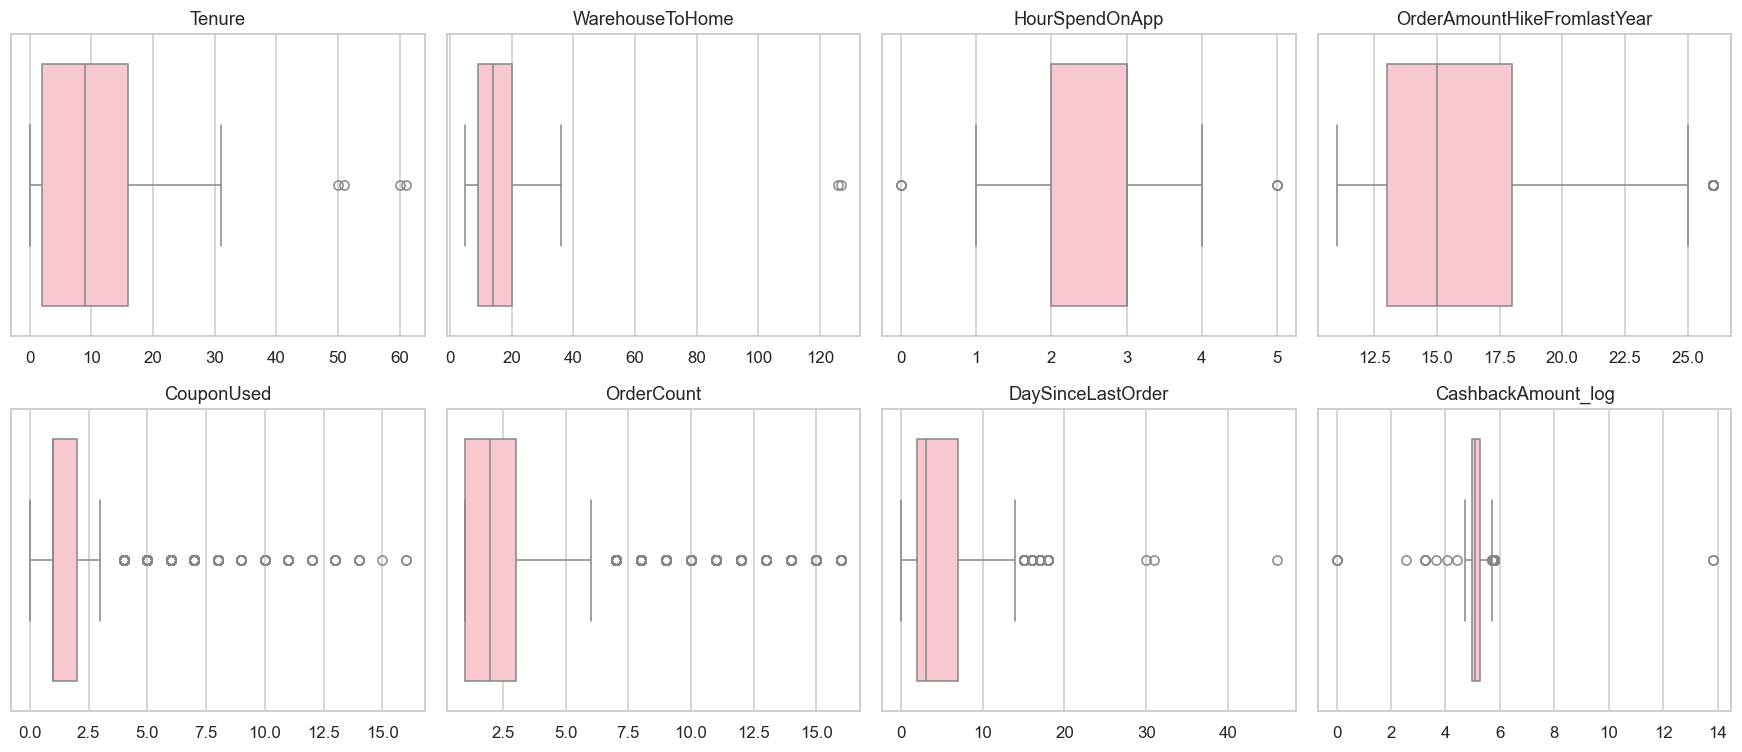

In [21]:
# Boxplots for visual outlier inspection
# CashbackAmount is log-transformed only for visualization, because one extreme value makes the raw scale unreadable.
plot_data = df[audit_cols].copy()

if "CashbackAmount" in plot_data.columns:
    plot_data["CashbackAmount_log"] = np.log1p(plot_data["CashbackAmount"])
    plot_cols = [col for col in audit_cols if col != "CashbackAmount"] + ["CashbackAmount_log"]
else:
    plot_cols = audit_cols

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(x=plot_data[col], ax=axes[i], color="pink")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused axes if any
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- The main binary and bounded variables are consistent: `Churn` and `Complain` contain valid 0/1 values, and `SatisfactionScore` stays within the expected 1–5 range.
- No negative values are found in the behavioral variables, so there are no obvious impossible values in counts, tenure, distance or order timing.
- `WarehouseToHome` shows a very small number of extreme values above 100. Since this variable represents delivery distance or delivery effort, these observations should be treated cautiously in the cleaning step.
- `CashbackAmount` contains extreme values above the normal distribution of the variable. These are likely data entry anomalies rather than realistic cashback amounts.
- Several variables such as `CouponUsed`, `OrderCount` and `DaySinceLastOrder` show statistical outliers, but they may reflect real customer behavior, such as frequent purchasing, high coupon usage or long inactivity.

## A.5 Cleaning strategy and implementation

Based on the audit, cleaning is applied selectively.

The objective is to preserve as many customers as possible for churn modeling while correcting only clear data-quality issues. Behavioral outliers are not automatically removed, because they may contain useful churn signals.

In [23]:
# Create a raw copy and a cleaned working dataframe
df_raw = df.copy()
df_clean = df.copy()

cleaning_steps = []

# 1. Remove only exact duplicate rows
n_duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()

cleaning_steps.append({
    "Issue": "Exact duplicated rows",
    "Action": "Drop duplicates",
    "Reason": "Exact duplicate records can over-represent the same observation",
    "Rows_Affected": int(n_duplicates)
})

# 2. Remove rows with missing CustomerID
# CustomerID is an identifier and cannot be meaningfully imputed
n_missing_customer_id = df_clean["CustomerID"].isna().sum()
df_clean = df_clean.dropna(subset=["CustomerID"]).copy()

cleaning_steps.append({
    "Issue": "Missing CustomerID",
    "Action": "Drop rows",
    "Reason": "CustomerID is an identifier and cannot be reliably imputed",
    "Rows_Affected": int(n_missing_customer_id)
})

# 3. Remove rows with missing Gender
# Only a negligible number of rows is affected
n_missing_gender = df_clean["Gender"].isna().sum()
df_clean = df_clean.dropna(subset=["Gender"]).copy()

cleaning_steps.append({
    "Issue": "Missing Gender",
    "Action": "Drop rows",
    "Reason": "Very small missingness; avoids artificial demographic imputation",
    "Rows_Affected": int(n_missing_gender)
})

# 4. Treat obvious categorical placeholder values as missing
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()

placeholder_values = ["N.A.", "NA", "N/A", "na", "n/a", "Unknown", "unknown", ""]

n_placeholder_values = 0

for col in cat_cols:
    n_placeholders_col = df_clean[col].isin(placeholder_values).sum()
    n_placeholder_values += n_placeholders_col
    df_clean[col] = df_clean[col].replace(placeholder_values, np.nan)

cleaning_steps.append({
    "Issue": "Categorical placeholder values",
    "Action": "Set to missing",
    "Reason": "Placeholder labels should not become separate encoded categories",
    "Rows_Affected": int(n_placeholder_values)
})

# 5. Standardize inconsistent categorical labels before encoding
category_replacements = {
    "PreferredLoginDevice": {
        "Mobile Phone": "Mobile",
        "Phone": "Mobile"
    },
    "PreferredPaymentMode": {
        "CC": "Credit Card",
        "COD": "Cash on Delivery"
    },
    "PreferedOrderCat": {
        "Mobile Phone": "Mobile"
    }
}

for col, mapping in category_replacements.items():
    if col in df_clean.columns:
        n_replaced = df_clean[col].isin(mapping.keys()).sum()
        df_clean[col] = df_clean[col].replace(mapping)

        cleaning_steps.append({
            "Issue": f"Inconsistent labels in {col}",
            "Action": "Standardize category labels",
            "Reason": "Avoid redundant categories before one-hot encoding",
            "Rows_Affected": int(n_replaced)
        })

# 6. Treat clearly implausible numerical values as missing before imputation
n_extreme_warehouse = (df_clean["WarehouseToHome"] > 100).sum()
df_clean.loc[df_clean["WarehouseToHome"] > 100, "WarehouseToHome"] = np.nan

cleaning_steps.append({
    "Issue": "WarehouseToHome > 100",
    "Action": "Set to missing before imputation",
    "Reason": "Extreme delivery-distance values are likely data-quality issues",
    "Rows_Affected": int(n_extreme_warehouse)
})

n_extreme_cashback = (df_clean["CashbackAmount"] > 1000).sum()
df_clean.loc[df_clean["CashbackAmount"] > 1000, "CashbackAmount"] = np.nan

cleaning_steps.append({
    "Issue": "CashbackAmount > 1000",
    "Action": "Set to missing before imputation",
    "Reason": "Extreme cashback values are likely data-entry errors",
    "Rows_Affected": int(n_extreme_cashback)
})

# 7. Median imputation for numerical missing values
# CustomerID and Churn are excluded from imputation
numeric_cols_to_impute = (
    df_clean
    .select_dtypes(include=["int64", "float64"])
    .columns
    .drop(["CustomerID", "Churn"], errors="ignore")
)

numeric_missing_before = df_clean[numeric_cols_to_impute].isna().sum()
total_numeric_missing = numeric_missing_before.sum()

for col in numeric_cols_to_impute:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

cleaning_steps.append({
    "Issue": "Missing numerical values",
    "Action": "Median imputation",
    "Reason": "Median is robust to skewed distributions and outliers",
    "Rows_Affected": int(total_numeric_missing)
})

# 8. Mode imputation for remaining categorical missing values
cat_cols_to_impute = df_clean.select_dtypes(include="object").columns.tolist()

categorical_missing_before = df_clean[cat_cols_to_impute].isna().sum()
total_categorical_missing = categorical_missing_before.sum()

for col in cat_cols_to_impute:
    if df_clean[col].isna().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)

cleaning_steps.append({
    "Issue": "Missing categorical values",
    "Action": "Mode imputation",
    "Reason": "Used only for remaining categorical missingness after standardization",
    "Rows_Affected": int(total_categorical_missing)
})

# Create cleaning log
cleaning_log = pd.DataFrame(cleaning_steps)

# Final cleaning checks
print(f"Original rows: {len(df_raw)}")
print(f"Cleaned rows:  {len(df_clean)}")
print(f"Rows removed:  {len(df_raw) - len(df_clean)}")
print(f"Remaining missing values: {df_clean.isna().sum().sum()}")
print(f"Remaining duplicated rows: {df_clean.duplicated().sum()}")
print(f"Remaining WarehouseToHome > 100: {(df_clean['WarehouseToHome'] > 100).sum()}")
print(f"Remaining CashbackAmount > 1000: {(df_clean['CashbackAmount'] > 1000).sum()}")

display(cleaning_log)

# Compact categorical check after standardization
cat_summary_after_cleaning = pd.DataFrame({
    "Categorical Column": cat_cols_to_impute,
    "Unique Values After Cleaning": [df_clean[col].nunique() for col in cat_cols_to_impute],
    "Categories": [sorted(df_clean[col].unique()) for col in cat_cols_to_impute]
})

display(cat_summary_after_cleaning)

Original rows: 5630
Cleaned rows:  5626
Rows removed:  4
Remaining missing values: 0
Remaining duplicated rows: 0
Remaining WarehouseToHome > 100: 0
Remaining CashbackAmount > 1000: 0


,Issue,Action,Reason,Rows_Affected
0,Exact duplicated rows,Drop duplicates,Exact duplicate records can over-represent the...,0
1,Missing CustomerID,Drop rows,CustomerID is an identifier and cannot be reli...,2
2,Missing Gender,Drop rows,Very small missingness; avoids artificial demo...,2
3,Categorical placeholder values,Set to missing,Placeholder labels should not become separate ...,5
4,Inconsistent labels in PreferredLoginDevice,Standardize category labels,Avoid redundant categories before one-hot enco...,3991
5,Inconsistent labels in PreferredPaymentMode,Standardize category labels,Avoid redundant categories before one-hot enco...,638
6,Inconsistent labels in PreferedOrderCat,Standardize category labels,Avoid redundant categories before one-hot enco...,1270
7,WarehouseToHome > 100,Set to missing before imputation,Extreme delivery-distance values are likely da...,2
8,CashbackAmount > 1000,Set to missing before imputation,Extreme cashback values are likely data-entry ...,2
9,Missing numerical values,Median imputation,Median is robust to skewed distributions and o...,1860


,Categorical Column,Unique Values After Cleaning,Categories
0,PreferredLoginDevice,2,"[Computer, Mobile]"
1,PreferredPaymentMode,5,"[Cash on Delivery, Credit Card, Debit Card, E ..."
2,Gender,2,"[Female, Male]"
3,PreferedOrderCat,5,"[Fashion, Grocery, Laptop & Accessory, Mobile,..."
4,MaritalStatus,4,"[Divorced, Married, Single, Widow]"


**Cleaning strategy — interpretation**

- The cleaning process is conservative: the dataset decreases from **5,630** to **5,626** rows, meaning that only **4 records** are removed.
- Rows with missing `CustomerID` are removed because the customer identifier cannot be reliably imputed. Rows with missing `Gender` are also removed because only **2 observations** are affected.
- Placeholder categorical values are treated as missing and then imputed with the mode, preventing placeholder labels from becoming separate categories during encoding.
- Inconsistent categorical labels are standardized before encoding, reducing redundant categories such as different labels for mobile devices or payment methods.
- Extreme values in `WarehouseToHome` and `CashbackAmount` are treated as data-quality issues and set to missing before median imputation.
- Numerical missing values are imputed with the median, which is robust to skewed distributions and outliers.
- No one-hot encoding is applied in this section; categorical encoding is performed separately in the next step.
- Behavioral outliers are preserved because they may contain useful churn signals for the predictive model.

## A.6 Categorical encoding

Machine learning models require numerical input features.  
In this section, categorical variables are converted into dummy variables using one-hot encoding.

`CustomerID` is removed because it is only an identifier and should not be used as a predictive feature.

In [24]:
# Create modeling dataframe from the cleaned dataset
df_model = df_clean.copy()

# Remove CustomerID because it is only an identifier, not a predictive feature
df_model = df_model.drop(columns=["CustomerID"], errors="ignore")

# Identify categorical columns after cleaning
cat_cols_clean = df_model.select_dtypes(include="object").columns.tolist()

print("Categorical columns to encode:")
print(cat_cols_clean)

# One-hot encoding for categorical variables
# drop_first=True avoids redundant dummy variables
df_model = pd.get_dummies(
    df_model,
    columns=cat_cols_clean,
    drop_first=True
)

# Convert boolean dummy columns to integers if needed
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Final encoding check
encoding_summary = pd.DataFrame({
    "Check": [
        "Original cleaned dataframe shape",
        "Model dataframe shape after encoding",
        "Remaining missing values",
        "Remaining object columns",
        "Target variable present"
    ],
    "Result": [
        df_clean.shape,
        df_model.shape,
        df_model.isna().sum().sum(),
        df_model.select_dtypes(include="object").shape[1],
        "Churn" in df_model.columns
    ]
})

display(encoding_summary)

display(df_model.head())

Categorical columns to encode:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


,Check,Result
0,Original cleaned dataframe shape,"(5626, 20)"
1,Model dataframe shape after encoding,"(5626, 27)"
2,Remaining missing values,0
3,Remaining object columns,0
4,Target variable present,True


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widow
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160.0,1,0,1,0,0,0,0,1,0,0,0,1,0
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121.0,1,0,0,0,1,1,0,0,1,0,0,1,0
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.0,1,0,1,0,0,1,0,0,1,0,0,1,0
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.0,1,0,1,0,0,1,0,1,0,0,0,1,0
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,130.0,1,1,0,0,0,1,0,0,1,0,0,1,0


**Categorical encoding — interpretation**

- The categorical variables `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat` and `MaritalStatus` were converted into numerical dummy variables using one-hot encoding.
- `CustomerID` was removed because it is only an identifier and should not be used as a predictive feature.
- `drop_first=True` was applied to avoid redundant dummy variables and reduce multicollinearity.
- After encoding, the modeling dataframe contains **5,626 rows and 27 columns**, with no missing values and no remaining object-type columns.

## A.7 Final quality check

Before moving to EDA and modeling, we perform a final quality check on both the cleaned dataset and the encoded modeling dataframe.

The goal is to verify that missing values, duplicates, extreme errors and categorical variables have been handled correctly.

In [25]:
# Final quality check after cleaning and encoding

final_quality_check = pd.DataFrame({
    "Check": [
        "Original dataset shape",
        "Cleaned dataset shape",
        "Model dataframe shape",
        "Rows removed during cleaning",
        "Missing values in cleaned dataset",
        "Missing values in model dataframe",
        "Duplicated rows in cleaned dataset",
        "Remaining object columns in model dataframe",
        "CustomerID removed from model dataframe",
        "Target variable preserved"
    ],
    "Result": [
        df.shape,
        df_clean.shape,
        df_model.shape,
        len(df) - len(df_clean),
        df_clean.isna().sum().sum(),
        df_model.isna().sum().sum(),
        df_clean.duplicated().sum(),
        df_model.select_dtypes(include="object").shape[1],
        "CustomerID" not in df_model.columns,
        "Churn" in df_model.columns
    ]
})

display(final_quality_check)

# Check target distribution after cleaning
churn_distribution = (
    df_clean["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customer_Count")
)

churn_distribution["Customer_Share_%"] = (
    churn_distribution["Customer_Count"] / len(df_clean) * 100
).round(2)

display(churn_distribution)

# Final numerical summary for key variables after cleaning
key_numeric_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

key_numeric_cols = [col for col in key_numeric_cols if col in df_clean.columns]

display(df_clean[key_numeric_cols].describe().T.round(2))

,Check,Result
0,Original dataset shape,"(5630, 20)"
1,Cleaned dataset shape,"(5626, 20)"
2,Model dataframe shape,"(5626, 27)"
3,Rows removed during cleaning,4
4,Missing values in cleaned dataset,0
5,Missing values in model dataframe,0
6,Duplicated rows in cleaned dataset,0
7,Remaining object columns in model dataframe,0
8,CustomerID removed from model dataframe,True
9,Target variable preserved,True


,Churn,Customer_Count,Customer_Share_%
0,0,4679,83.17
1,1,947,16.83


,count,mean,std,min,25%,50%,75%,max
Tenure,5626.0,10.14,8.36,0.0,3.0,9.0,15.0,61.0
WarehouseToHome,5626.0,15.52,8.08,5.0,9.0,14.0,20.0,36.0
HourSpendOnApp,5626.0,2.93,0.71,0.0,2.0,3.0,3.0,5.0
OrderAmountHikeFromlastYear,5626.0,15.68,3.59,11.0,13.0,15.0,18.0,26.0
CouponUsed,5626.0,1.72,1.86,0.0,1.0,1.0,2.0,16.0
OrderCount,5626.0,2.96,2.88,1.0,1.0,2.0,3.0,16.0
DaySinceLastOrder,5626.0,4.46,3.57,0.0,2.0,3.0,7.0,46.0
CashbackAmount,5626.0,177.23,49.21,0.0,146.0,163.0,196.0,325.0


## Task A Summary

Task A performed a full data audit and cleaning process to prepare the ecommerce churn dataset for EDA and supervised modeling.

The dataset originally contained **5,630 rows and 20 columns**. The target variable is `Churn`, while `CustomerID` was identified as a customer identifier and removed from the modeling dataframe.

The data audit showed both numerical and categorical variables. Categorical variables such as `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat` and `MaritalStatus` required preprocessing before modeling.

Missing values were concentrated in a limited group of variables, mainly behavioral features such as `DaySinceLastOrder`, `OrderAmountHikeFromlastYear`, `Tenure`, `OrderCount`, `CouponUsed`, `HourSpendOnApp` and `WarehouseToHome`. Since no column exceeded about **6% missingness**, dropping entire columns was not justified. Numerical missing values were therefore imputed using the median, which is robust to skewed distributions and outliers.

The cleaning process was conservative: only **4 rows** were removed, corresponding to missing `CustomerID` and missing `Gender`. Extreme values in `WarehouseToHome` and `CashbackAmount` were treated as data-quality issues and set to missing before median imputation. Behavioral outliers such as high `CouponUsed`, `OrderCount` and `DaySinceLastOrder` were preserved because they may contain useful churn signals.

Categorical labels were standardized before encoding to avoid redundant categories, and then one-hot encoding was applied using `drop_first=True`. The final modeling dataframe `df_model` contains **5,626 rows and 27 columns**, with no missing values and no remaining categorical object columns.

# Task B — Exploratory Data Analysis (EDA)

This section explores the relationship between customer behavior and churn.

The goal is to understand whether the dataset is imbalanced, how customer satisfaction and complaints relate to churn, and how behavioral variables such as `Tenure` and `DaySinceLastOrder` influence churn probability.

## B.1 Class balance

Before analyzing churn drivers, we first inspect the distribution of the target variable.

This is important because churn prediction often involves imbalanced datasets, where churners represent a minority of customers.

,Churn,Churn_Label,Customer_Count,Customer_Share_%
0,0,Non-churner,4679,83.17
1,1,Churner,947,16.83


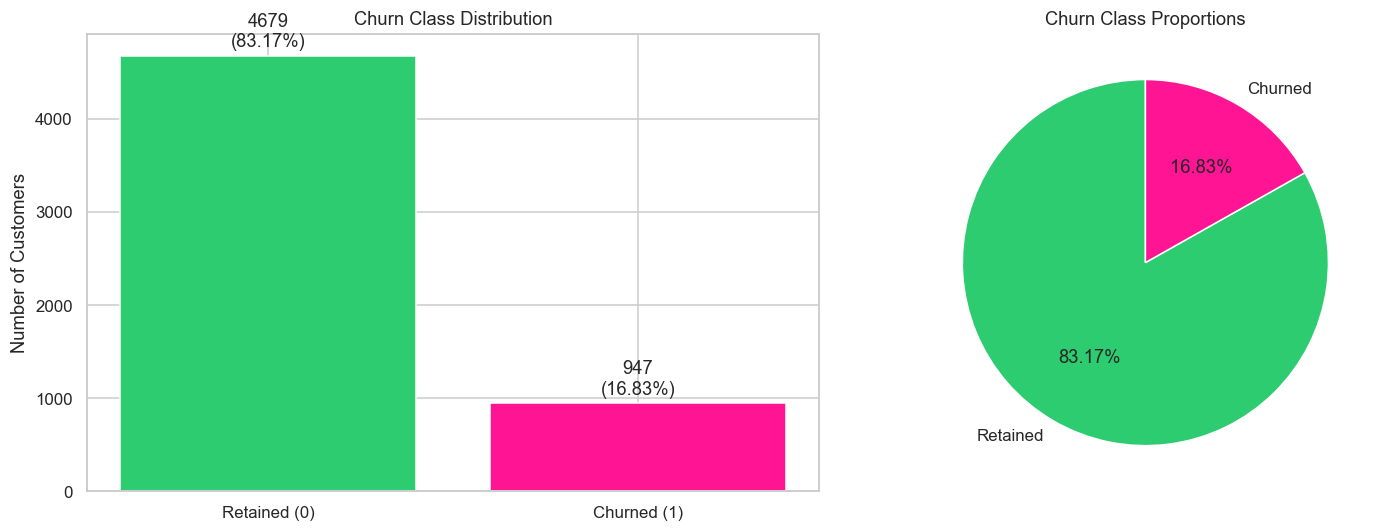

Imbalance ratio: 4.9:1


In [30]:
# Churn class balance
df_eda = df_clean.copy()

churn_counts = df_eda["Churn"].value_counts().sort_index()
churn_percentages = (churn_counts / len(df_eda) * 100).round(2)

churn_labels = ["Retained (0)", "Churned (1)"]

churn_distribution = pd.DataFrame({
    "Churn": churn_counts.index,
    "Churn_Label": ["Non-churner", "Churner"],
    "Customer_Count": churn_counts.values,
    "Customer_Share_%": churn_percentages.values
})

display(churn_distribution)

# Plot class balance: count bar chart + proportion pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    churn_labels,
    churn_counts.values,
    color =[ "#2ECC71", "#FF1493"]
)

axes[0].set_title("Churn Class Distribution")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("")

for bar, count, pct in zip(bars, churn_counts.values, churn_percentages.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count}\n({pct:.2f}%)",
        ha="center",
        va="bottom"
    )

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=["Retained", "Churned"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#2ECC71", "#FF1493"]
)

axes[1].set_title("Churn Class Proportions")

plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {churn_counts[0] / churn_counts[1]:.1f}:1")

- The dataset is clearly skewed toward retained customers: **4,679 customers** did not churn, while **947 customers** churned.
- Churners represent only **16.83%** of the cleaned dataset, while retained customers represent **83.17%**.
- The imbalance ratio is approximately **4.9 retained customers for every churned customer**.

## B.2 Correlation between complaints, satisfaction and churn

This section analyzes the relationship between `Complain`, `SatisfactionScore` and `Churn`.

The goal is to understand whether complaints and satisfaction levels are associated with a higher probability of customer churn.

,Complain,SatisfactionScore,Churn
Complain,1.000,-0.031,0.250
SatisfactionScore,-0.031,1.000,0.105
Churn,0.250,0.105,1.000


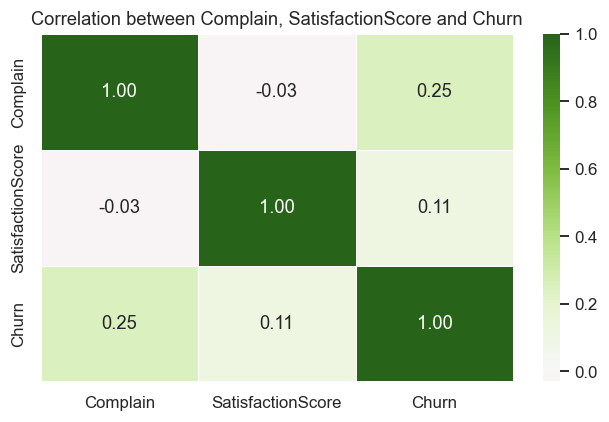

In [31]:
# Variables required by the task
corr_vars = ["Complain", "SatisfactionScore", "Churn"]

# Correlation matrix
corr_matrix = df_eda[corr_vars].corr()

display(corr_matrix.round(3))

# Heatmap of correlations
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="PiYG",
    center=0,
    linewidths=0.5
)

plt.title("Correlation between Complain, SatisfactionScore and Churn")
plt.tight_layout()
plt.show()

The correlation heatmap provides a first linear view of the relationship between `Complain`, `SatisfactionScore` and `Churn`, highlighting that `Complain` has the strongest association with churn among the three variables.

In [32]:
# Churn rate by complaint status
complain_churn = (
    df_eda
    .groupby("Complain")
    .agg(
        Customer_Count=("Churn", "count"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

complain_churn["Churn_Rate_%"] = (complain_churn["Churn_Rate"] * 100).round(2)
complain_churn["Complain_Label"] = complain_churn["Complain"].map({
    0: "No complaint",
    1: "Complaint"
})

display(complain_churn[["Complain", "Complain_Label", "Customer_Count", "Churn_Rate_%"]])

# Churn rate by satisfaction score
satisfaction_churn = (
    df_eda
    .groupby("SatisfactionScore")
    .agg(
        Customer_Count=("Churn", "count"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

satisfaction_churn["Churn_Rate_%"] = (satisfaction_churn["Churn_Rate"] * 100).round(2)

display(satisfaction_churn)

,Complain,Complain_Label,Customer_Count,Churn_Rate_%
0,0,No complaint,4025,10.93
1,1,Complaint,1601,31.67


,SatisfactionScore,Customer_Count,Churn_Rate,Churn_Rate_%
0,1,1162,0.115318,11.53
1,2,586,0.126280,12.63
2,3,1697,0.172068,17.21
3,4,1073,0.170550,17.05
4,5,1108,0.238267,23.83


The complaint-level churn table translates the correlation into a more interpretable business metric, showing how churn rate changes between customers with and without complaints.

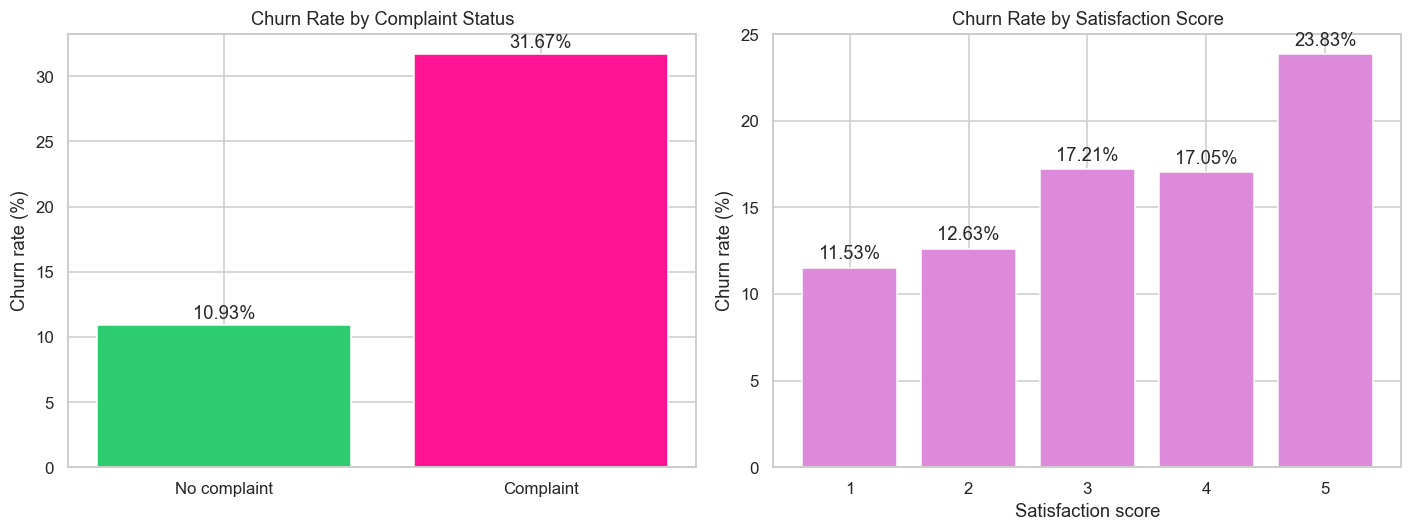

In [34]:
# Visualize churn rate by complaint and satisfaction score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate by complaint status
bars_1 = axes[0].bar(
    complain_churn["Complain_Label"],
    complain_churn["Churn_Rate_%"],
    color=["#2ECC71", "#FF1493"]
)

axes[0].set_title("Churn Rate by Complaint Status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn rate (%)")

for bar, value in zip(bars_1, complain_churn["Churn_Rate_%"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

# Churn rate by satisfaction score
bars_2 = axes[1].bar(
    satisfaction_churn["SatisfactionScore"].astype(str),
    satisfaction_churn["Churn_Rate_%"],
    color="#DE8ADA"
)

axes[1].set_title("Churn Rate by Satisfaction Score")
axes[1].set_xlabel("Satisfaction score")
axes[1].set_ylabel("Churn rate (%)")

for bar, value in zip(bars_2, satisfaction_churn["Churn_Rate_%"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

**Complaints, satisfaction and churn — interpretation**

- `Complain` is clearly associated with churn. Customers without complaints have a churn rate of **10.93%**, while customers who complained have a churn rate of **31.67%**.
- This confirms that complaints are an important churn-risk signal: customers who complain are almost three times more likely to churn than customers who do not complain.
- `SatisfactionScore` also shows variation in churn rate, although the relationship is less direct than for complaints. Churn increases from **11.53%** for score 1 to **23.83%** for score 5.
- The correlation matrix confirms this pattern: `Complain` has the strongest correlation with `Churn` (**0.25**), while `SatisfactionScore` has a weaker correlation (**0.11**).
- Overall, `Complain` appears to be the strongest customer-experience risk indicator in this section, while `SatisfactionScore` may still add useful information for the predictive model.

## B.3 Tenure and churn probability

This section analyzes whether customer tenure is associated with churn probability.

Customers are grouped into tenure bands to make the relationship easier to interpret and to identify whether newer or older customers are more likely to churn.

In [35]:
# Create tenure groups for clearer churn-rate analysis
df_eda["Tenure_Group"] = pd.cut(
    df_eda["Tenure"],
    bins=[-0.1, 3, 6, 12, 24, np.inf],
    labels=["0–3", "4–6", "7–12", "13–24", "25+"]
)

# Churn rate by tenure group
tenure_churn = (
    df_eda
    .groupby("Tenure_Group", observed=False)
    .agg(
        Customer_Count=("Churn", "count"),
        Churn_Rate=("Churn", "mean"),
        Avg_Tenure=("Tenure", "mean")
    )
    .reset_index()
)

tenure_churn["Churn_Rate_%"] = (tenure_churn["Churn_Rate"] * 100).round(2)
tenure_churn["Avg_Tenure"] = tenure_churn["Avg_Tenure"].round(2)

display(tenure_churn[["Tenure_Group", "Customer_Count", "Avg_Tenure", "Churn_Rate_%"]])

,Tenure_Group,Customer_Count,Avg_Tenure,Churn_Rate_%
0,0–3,1557,1.03,41.88
1,4–6,590,4.97,7.46
2,7–12,1584,9.28,9.85
3,13–24,1466,17.54,6.48
4,25+,429,28.19,0.00


The tenure-group table shows that churn is strongly concentrated among very recent customers, especially those with only **0–3 months** of tenure.

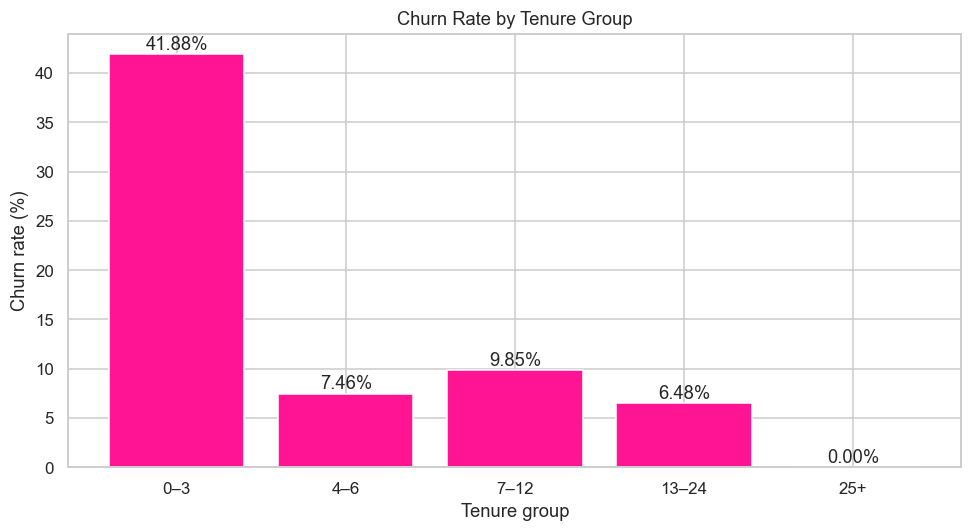

In [36]:
# Visualize churn probability by tenure group
plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_churn["Tenure_Group"].astype(str),
    tenure_churn["Churn_Rate_%"],
    color="#FF1493"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure group")
plt.ylabel("Churn rate (%)")

for bar, value in zip(bars, tenure_churn["Churn_Rate_%"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

The bar chart makes the pattern clear: customers in the **0–3 tenure group** have by far the highest churn rate, while churn drops sharply after the first months.

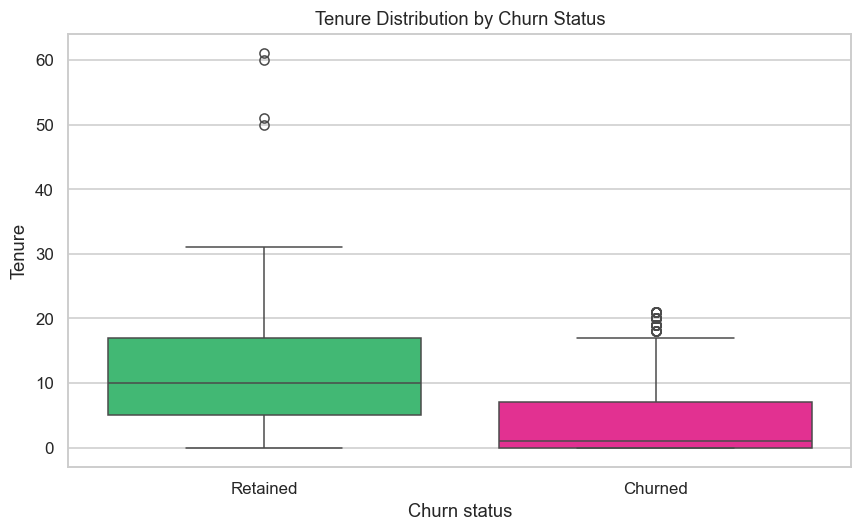

In [37]:
# Additional view: tenure distribution by churn status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Churn",
    y="Tenure",
    palette=["#2ECC71", "#FF1493"]
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn status")
plt.ylabel("Tenure")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.tight_layout()
plt.show()

The boxplot confirms that churned customers generally have lower tenure than retained customers, suggesting that early customer lifecycle is a critical churn-risk phase.

**Tenure and churn — interpretation**

- Tenure is strongly related to churn probability. Customers in the **0–3 tenure group** have the highest churn rate, around **41.89%**.
- After the first months, churn decreases sharply: the **4–6**, **7–12** and **13–24** groups show much lower churn rates.
- This suggests that churn risk is especially concentrated in the early customer lifecycle, when customers have not yet developed stable purchasing habits or loyalty.
- The boxplot supports the same conclusion: churned customers tend to have shorter tenure than retained customers.
- From a marketing perspective, this indicates that onboarding, early engagement and first-month retention actions should be prioritized.

## B.4 DaySinceLastOrder and churn probability

This section analyzes whether the number of days since the last order is associated with churn probability.

Customers are grouped into `DaySinceLastOrder` bands to make the relationship easier to interpret and to understand whether inactivity increases churn risk.

In [38]:
# Create DaySinceLastOrder groups for clearer churn-rate analysis
df_eda["DaySinceLastOrder_Group"] = pd.cut(
    df_eda["DaySinceLastOrder"],
    bins=[-0.1, 2, 5, 10, 20, np.inf],
    labels=["0–2", "3–5", "6–10", "11–20", "21+"]
)

# Churn rate by DaySinceLastOrder group
last_order_churn = (
    df_eda
    .groupby("DaySinceLastOrder_Group", observed=False)
    .agg(
        Customer_Count=("Churn", "count"),
        Avg_DaySinceLastOrder=("DaySinceLastOrder", "mean"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

last_order_churn["Avg_DaySinceLastOrder"] = last_order_churn["Avg_DaySinceLastOrder"].round(2)
last_order_churn["Churn_Rate_%"] = (last_order_churn["Churn_Rate"] * 100).round(2)

display(
    last_order_churn[
        ["DaySinceLastOrder_Group", "Customer_Count", "Avg_DaySinceLastOrder", "Churn_Rate_%"]
    ]
)

,DaySinceLastOrder_Group,Customer_Count,Avg_DaySinceLastOrder,Churn_Rate_%
0,0–2,1901,1.16,24.93
1,3–5,1864,3.47,14.43
2,6–10,1553,7.96,11.91
3,11–20,305,12.93,5.90
4,21+,3,35.67,33.33


The table shows a non-linear relationship between `DaySinceLastOrder` and churn: churn is high among very recent customers in the **0–2** group and also high in the **21+** group, although the latter contains very few customers.

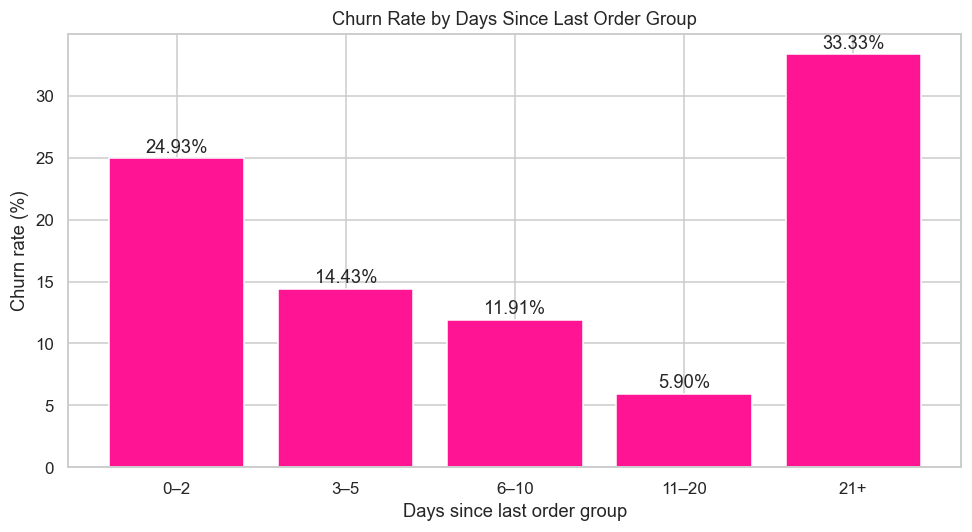

In [39]:
# Visualize churn probability by DaySinceLastOrder group
plt.figure(figsize=(9, 5))

bars = plt.bar(
    last_order_churn["DaySinceLastOrder_Group"].astype(str),
    last_order_churn["Churn_Rate_%"],
    color="#FF1493"
)

plt.title("Churn Rate by Days Since Last Order Group")
plt.xlabel("Days since last order group")
plt.ylabel("Churn rate (%)")

for bar, value in zip(bars, last_order_churn["Churn_Rate_%"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

The bar chart highlights that the highest churn rates are observed in the **0–2 days** group and in the **21+ days** group, while intermediate groups show lower churn risk.

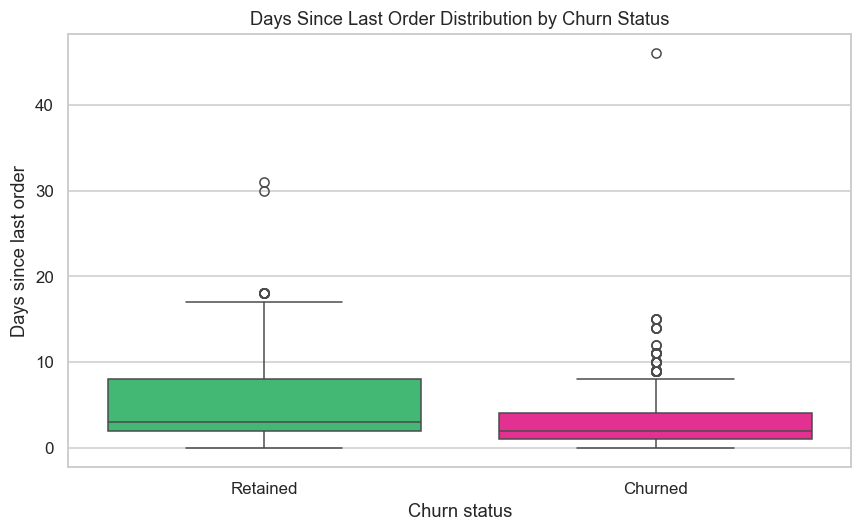

In [40]:
# Additional view: compare DaySinceLastOrder distribution by churn status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Churn",
    y="DaySinceLastOrder",
    palette=["#2ECC71", "#FF1493"]
)

plt.title("Days Since Last Order Distribution by Churn Status")
plt.xlabel("Churn status")
plt.ylabel("Days since last order")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.tight_layout()
plt.show()

The boxplot shows that churned customers are not simply those with the longest inactivity; many churned customers have relatively low `DaySinceLastOrder`, suggesting that churn is influenced by more than inactivity alone.

**DaySinceLastOrder and churn — interpretation**

- The relationship between `DaySinceLastOrder` and churn is not strictly linear.
- Customers in the **0–2 days** group show a high churn rate of **24.93%**, suggesting that some churn risk may occur even shortly after a recent order.
- The **21+ days** group shows the highest churn rate, around **33.33%**, but this result should be interpreted carefully because the group contains very few customers.
- Intermediate groups, especially **11–20 days**, show much lower churn rates, indicating that inactivity alone does not fully explain churn behavior.
- The boxplot confirms that churned customers are not only customers with long inactivity periods; therefore, `DaySinceLastOrder` should be combined with other variables such as `Tenure`, `Complain` and `SatisfactionScore` in the predictive model.

## Task B Summary

Task B explored the main behavioral and customer-experience variables related to churn.

The dataset is clearly imbalanced: **83.17%** of customers are retained, while only **16.83%** churn. This means that churners are the minority class, so model evaluation in Task C should focus not only on accuracy, but also on **recall** and **F1-score**.

The correlation analysis shows that `Complain` is the strongest churn-related signal among the selected customer-experience variables. Customers who complained have a churn rate of **31.67%**, compared with **10.93%** for customers without complaints. `SatisfactionScore` also varies with churn, but its relationship is weaker and less direct.

`Tenure` shows a very strong relationship with churn. Customers with **0–3 months** of tenure have the highest churn rate, around **41.89%**, while churn drops sharply after the first months. This suggests that early customer lifecycle is a critical phase for retention.

`DaySinceLastOrder` shows a more complex and non-linear relationship. Churn is high among customers in the **0–2 days** group and also in the **21+ days** group, although the latter contains few customers. This indicates that inactivity alone does not fully explain churn and should be interpreted together with other variables.

# Task C — Modeling & Evaluation

This task builds churn propensity models to predict which customers are more likely to churn.

Because the target variable is imbalanced, accuracy alone is not enough to evaluate model quality. A model could obtain high accuracy by mostly predicting the majority class, but still fail to identify churners

## C.1 Feature-target split and train-test split

The modeling dataframe `df_model` is used as input because it has already been cleaned and encoded in Task A.

The target variable is `Churn`, where `1` indicates a churned customer and `0` indicates a retained customer.  
All remaining columns are used as predictive features.

In [41]:
from sklearn.model_selection import train_test_split

# Define target and predictors
target = "Churn"

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Check target distribution before splitting
full_target_distribution = (
    y.value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customer_Count")
)

full_target_distribution["Customer_Share_%"] = (
    full_target_distribution["Customer_Count"] / len(y) * 100
).round(2)

display(full_target_distribution)

Feature matrix shape: (5626, 26)
Target vector shape: (5626,)


,Churn,Customer_Count,Customer_Share_%
0,0,4679,83.17
1,1,947,16.83


In [42]:
# Stratified train-test split preserves the churn/non-churn proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (3938, 26)
Testing set shape:  (1688, 26)


In [43]:
# Compare churn distribution across full, train and test sets
split_distribution = pd.DataFrame({
    "Dataset": ["Full dataset", "Training set", "Testing set"],
    "Total_Customers": [len(y), len(y_train), len(y_test)],
    "Churners": [y.sum(), y_train.sum(), y_test.sum()],
    "Non_Churners": [
        (y == 0).sum(),
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],
    "Churn_Rate_%": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

split_distribution["Churn_Rate_%"] = split_distribution["Churn_Rate_%"].round(2)

display(split_distribution)

,Dataset,Total_Customers,Churners,Non_Churners,Churn_Rate_%
0,Full dataset,5626,947,4679,16.83
1,Training set,3938,663,3275,16.84
2,Testing set,1688,284,1404,16.82


- The modeling dataset contains **5,626 customers** and **26 predictive features** after removing the target variable `Churn`.
- The target distribution confirms the class imbalance: **16.83%** of customers churned, while **83.17%** were retained.
- The data was split into **70% training set** and **30% testing set**, resulting in **3,938 training observations** and **1,688 testing observations**.
- Stratified sampling preserved the churn proportion across the splits: the training set has a churn rate of **16.84%**, while the testing set has a churn rate of **16.82%**.
- This is important because churners are the minority class, so the test set must remain representative for a fair evaluation of recall, F1-score and lift.

## C.2 Logistic Regression baseline

Logistic Regression is used as the baseline propensity model.

Since the target variable is imbalanced, `class_weight="balanced"` is used to give more importance to the minority class, namely churners.  
Numerical features are standardized inside a pipeline because Logistic Regression is sensitive to feature scale.

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Logistic Regression pipeline
log_reg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit the model
log_reg_model.fit(X_train, y_train)

# Predictions
log_reg_pred = log_reg_model.predict(X_test)
log_reg_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
log_reg_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_reg_pred),
    "Precision_Churn": precision_score(y_test, log_reg_pred, pos_label=1),
    "Recall_Churn": recall_score(y_test, log_reg_pred, pos_label=1),
    "F1_Churn": f1_score(y_test, log_reg_pred, pos_label=1),
    "ROC_AUC": roc_auc_score(y_test, log_reg_proba)
}

log_reg_metrics_df = pd.DataFrame([log_reg_metrics])
display(log_reg_metrics_df.round(3))

print("Logistic Regression — classification report")
print(classification_report(
    y_test,
    log_reg_pred,
    target_names=["Retained", "Churned"]
))

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC
0,Logistic Regression,0.793,0.44,0.838,0.577,0.884


Logistic Regression — classification report
              precision    recall  f1-score   support

    Retained       0.96      0.78      0.86      1404
     Churned       0.44      0.84      0.58       284

    accuracy                           0.79      1688
   macro avg       0.70      0.81      0.72      1688
weighted avg       0.87      0.79      0.82      1688



- Logistic Regression achieves an overall accuracy of **0.793**, but accuracy alone is not sufficient because the dataset is imbalanced.
- The model performs well in identifying churners, with a `Recall_Churn` of **0.838**. This means it correctly captures most customers who actually churned.
- However, `Precision_Churn` is only **0.440**, meaning that many customers predicted as churners are actually retained customers.
- This trade-off is acceptable for a churn prevention context, because missing a real churner is usually more costly than contacting some customers who would have stayed anyway.
- The `ROC_AUC` of **0.884** indicates that the model has good ability to distinguish between churners and non-churners.
- Logistic Regression therefore provides a strong and interpretable baseline, but it should be compared with a more flexible model such as Random Forest.

## C.3 Random Forest model

Random Forest is used as a second propensity model because it can capture non-linear relationships and interactions between customer features.

Unlike Logistic Regression, Random Forest does not require feature scaling. Since churners are the minority class, `class_weight="balanced"` is used to reduce the impact of class imbalance.

In [61]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Fit the model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision_Churn": precision_score(y_test, rf_pred, pos_label=1),
    "Recall_Churn": recall_score(y_test, rf_pred, pos_label=1),
    "F1_Churn": f1_score(y_test, rf_pred, pos_label=1),
    "ROC_AUC": roc_auc_score(y_test, rf_proba)
}

rf_metrics_df = pd.DataFrame([rf_metrics])
display(rf_metrics_df.round(3))

print("Random Forest — classification report")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Retained", "Churned"]
))

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC
0,Random Forest,0.928,0.745,0.873,0.804,0.976


Random Forest — classification report
              precision    recall  f1-score   support

    Retained       0.97      0.94      0.96      1404
     Churned       0.74      0.87      0.80       284

    accuracy                           0.93      1688
   macro avg       0.86      0.91      0.88      1688
weighted avg       0.93      0.93      0.93      1688



- Random Forest achieves a very strong overall performance, with an accuracy of **0.928** and a `ROC_AUC` of **0.976**.
- Compared with Logistic Regression, it substantially improves `Precision_Churn` from **0.440** to **0.745**, meaning that fewer retained customers are incorrectly classified as churners.
- `Recall_Churn` remains high at **0.873**, so the model still captures most customers who actually churned.
- The `F1_Churn` score reaches **0.804**, showing a much better balance between precision and recall than the Logistic Regression baseline.
- This makes Random Forest a stronger candidate for the final churn propensity model, especially because it identifies churners effectively while reducing unnecessary retention actions on loyal customers.

## C.4 Model comparison

This section compares Logistic Regression and Random Forest using both summary metrics and threshold-based curves.

The bar plot compares the main classification metrics: `Accuracy`, `Precision_Churn`, `Recall_Churn` and `F1_Churn`.

The ROC curve and the Precision-Recall curve provide an additional view of model performance across different classification thresholds. The ROC curve evaluates how well each model separates churners from retained customers, while the Precision-Recall curve is especially useful because the positive class, churners, is imbalanced.

In [58]:
# Combine model metrics into one comparison table
model_comparison = pd.concat(
    [log_reg_metrics_df, rf_metrics_df],
    ignore_index=True
)

# Order columns for readability
model_comparison = model_comparison[
    [
        "Model",
        "Accuracy",
        "Precision_Churn",
        "Recall_Churn",
        "F1_Churn"
    ]
]

display(model_comparison.round(3))

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn
0,Logistic Regression,0.793,0.440,0.838,0.577
1,Random Forest,0.928,0.745,0.873,0.804


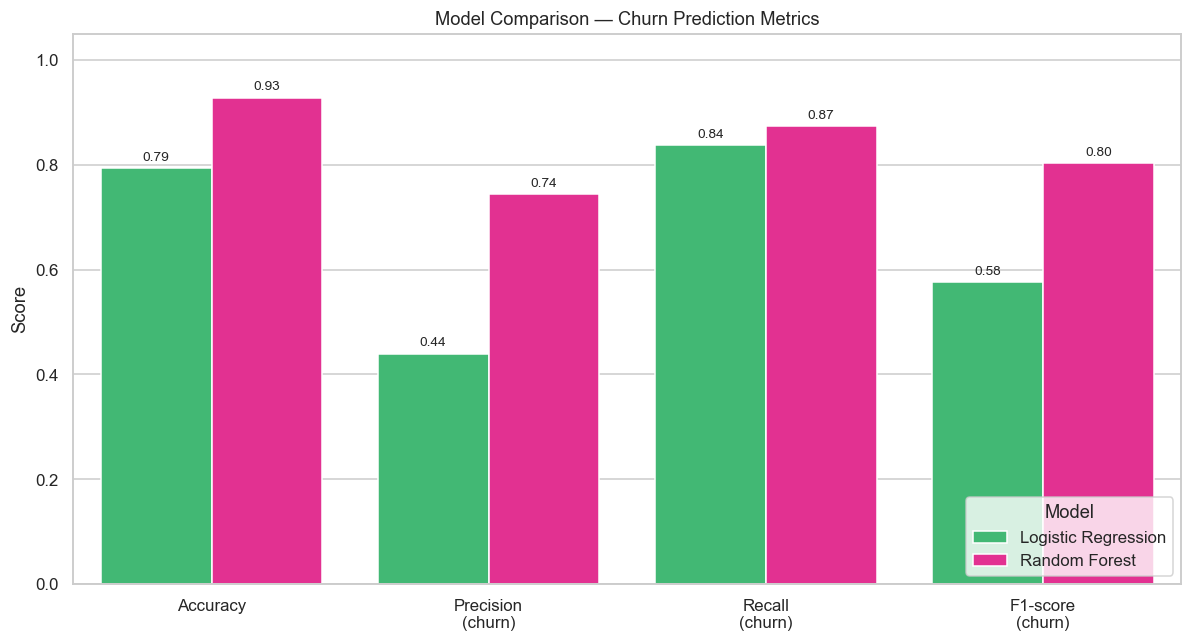

In [57]:
# Create a long-format table for plotting
metrics_to_plot = [
    "Accuracy",
    "Precision_Churn",
    "Recall_Churn",
    "F1_Churn",
    "ROC_AUC"
]

comparison_plot = model_comparison.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

# Clean metric labels for the chart
metric_labels = {
    "Accuracy": "Accuracy",
    "Precision_Churn": "Precision\n(churn)",
    "Recall_Churn": "Recall\n(churn)",
    "F1_Churn": "F1-score\n(churn)"
}

comparison_plot["Metric_Label"] = comparison_plot["Metric"].map(metric_labels)

# Plot grouped bar chart
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparison_plot,
    x="Metric_Label",
    y="Score",
    hue="Model",
    palette={
        "Logistic Regression": "#2ECC71",
        "Random Forest": "#FF1493"
    }
)

plt.title("Model Comparison — Churn Prediction Metrics")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Model", loc="lower right")

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.2f}" for v in container],
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

The bar plot shows that Random Forest outperforms Logistic Regression on the main churn prediction metrics. Logistic Regression has good recall, but much lower precision, meaning it identifies many churners but also produces many false alarms. Random Forest improves precision and F1-score while maintaining high recall, making it more balanced for churn prevention.

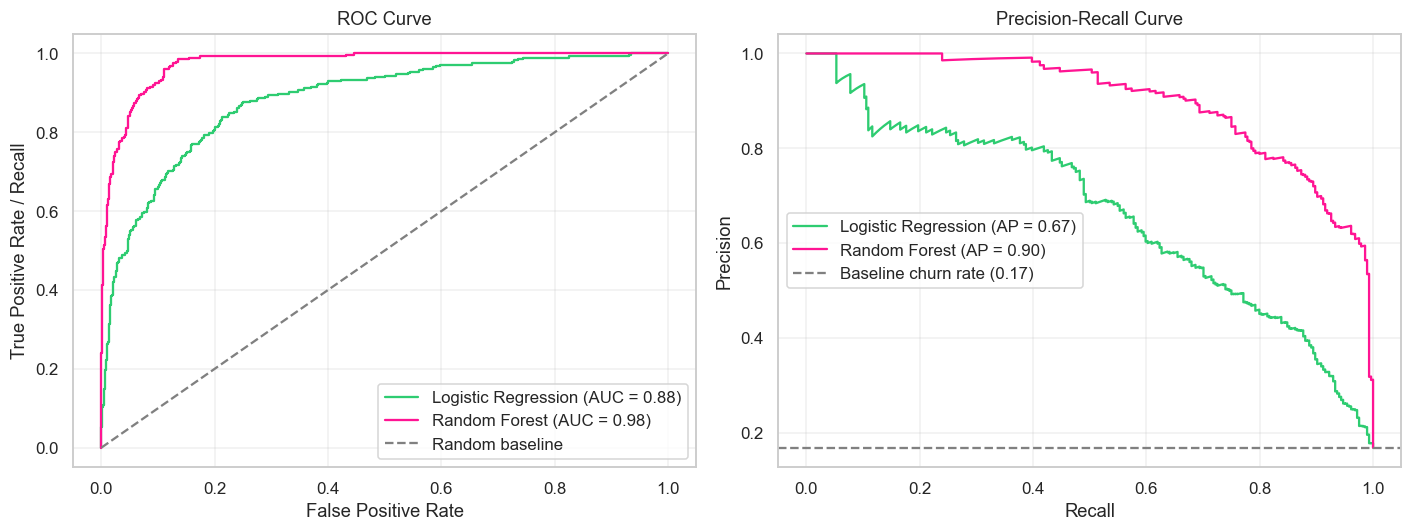

In [56]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# ROC curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_reg_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

log_roc_auc = auc(log_fpr, log_tpr)
rf_roc_auc = auc(rf_fpr, rf_tpr)

# Precision-Recall curves
log_precision, log_recall, _ = precision_recall_curve(y_test, log_reg_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_proba)

log_ap = average_precision_score(y_test, log_reg_proba)
rf_ap = average_precision_score(y_test, rf_proba)

baseline_churn_rate = y_test.mean()

# Plot ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(
    log_fpr,
    log_tpr,
    color="#2ECC71",
    label=f"Logistic Regression (AUC = {log_roc_auc:.2f})"
)

axes[0].plot(
    rf_fpr,
    rf_tpr,
    color="#FF1493",
    label=f"Random Forest (AUC = {rf_roc_auc:.2f})"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)

axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Precision-Recall curve
axes[1].plot(
    log_recall,
    log_precision,
    color="#2ECC71",
    label=f"Logistic Regression (AP = {log_ap:.2f})"
)

axes[1].plot(
    rf_recall,
    rf_precision,
    color="#FF1493",
    label=f"Random Forest (AP = {rf_ap:.2f})"
)

axes[1].axhline(
    y=baseline_churn_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline churn rate ({baseline_churn_rate:.2f})"
)

axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The ROC curve confirms that Random Forest separates churners from retained customers better than Logistic Regression. The Precision-Recall curve is even more relevant in this imbalanced setting: Random Forest maintains higher precision across most recall levels.

## C.6 Confusion matrix

The confusion matrix shows how many customers are correctly or incorrectly classified by each model.

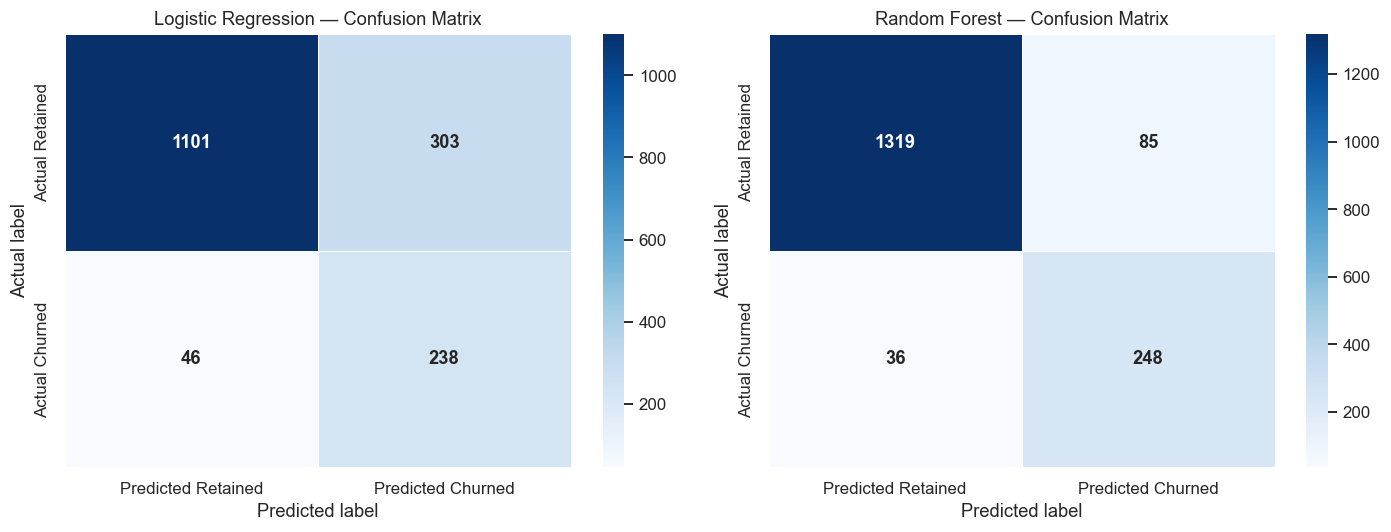

In [51]:
# Create confusion matrices
log_reg_cm = confusion_matrix(y_test, log_reg_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

# Plot both confusion matrices with clearer colors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_cm = [
    ("Logistic Regression", log_reg_cm),
    ("Random Forest", rf_cm)
]

for ax, (model_name, cm) in zip(axes, models_cm):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Predicted Retained", "Predicted Churned"],
        yticklabels=["Actual Retained", "Actual Churned"],
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"}
    )
    
    ax.set_title(f"{model_name} — Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()

In [52]:
def confusion_summary(cm, model_name):
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Recall Churn": tp / (tp + fn),
        "Precision Churn": tp / (tp + fp)
    }

confusion_comparison = pd.DataFrame([
    confusion_summary(log_reg_cm, "Logistic Regression"),
    confusion_summary(rf_cm, "Random Forest")
])

display(confusion_comparison.round(3))

,Model,True Negatives,False Positives,False Negatives,True Positives,Recall Churn,Precision Churn
0,Logistic Regression,1101,303,46,238,0.838,0.440
1,Random Forest,1319,85,36,248,0.873,0.745



The confusion matrices show that Random Forest provides the best operational balance for churn prediction.

Logistic Regression correctly identifies **238 churners**, but misses **46 actual churners** who are incorrectly classified as retained customers. Its churn recall is **0.838**. However, it also generates **303 false positives**, meaning that many retained customers are incorrectly flagged as at risk.

Random Forest performs better overall: it correctly identifies **248 churners** and misses only **36 actual churners**, reaching a higher churn recall of **0.873**. At the same time, it strongly reduces false positives from **303** to **85**, meaning that fewer loyal customers would receive unnecessary retention actions.

**Why recall matters in churn prediction**

In churn prediction, recall is especially important because false negatives are the most costly error. A false negative is a customer who actually churns but is predicted as retained; in this case, the company would not intervene and could lose the customer completely. A false positive is less damaging, because it usually only means contacting a customer who would have stayed anyway.

For this reason, catching a potential churner is more important than mistakenly targeting a loyal customer. 

## C.7 Lift analysis — top-risk customers

Lift analysis evaluates whether the model is useful for marketing prioritization.

Instead of contacting all customers, the company can rank customers by predicted churn probability and focus retention actions on the highest-risk groups.  
A lift greater than 1 means that the selected group contains more churners than a random selection of customers.

In [53]:
# Lift analysis using the selected model: Random Forest

lift_df = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn_Probability": rf_proba
})

# Sort customers from highest to lowest predicted churn risk
lift_df = lift_df.sort_values(
    "Predicted_Churn_Probability",
    ascending=False
).reset_index(drop=True)

# Create deciles: D1 = highest predicted risk, D10 = lowest predicted risk
lift_df["Risk_Decile"] = pd.qcut(
    lift_df.index + 1,
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

# Baseline churn rate in the test set
baseline_churn_rate = lift_df["Actual_Churn"].mean()

# Compute lift by decile
lift_summary = (
    lift_df
    .groupby("Risk_Decile", observed=False)
    .agg(
        Customer_Count=("Actual_Churn", "count"),
        Churners=("Actual_Churn", "sum"),
        Avg_Predicted_Risk=("Predicted_Churn_Probability", "mean"),
        Actual_Churn_Rate=("Actual_Churn", "mean")
    )
    .reset_index()
)

lift_summary["Actual_Churn_Rate_%"] = (
    lift_summary["Actual_Churn_Rate"] * 100
).round(2)

lift_summary["Avg_Predicted_Risk_%"] = (
    lift_summary["Avg_Predicted_Risk"] * 100
).round(2)

lift_summary["Lift"] = (
    lift_summary["Actual_Churn_Rate"] / baseline_churn_rate
).round(2)

# Add cumulative metrics
lift_summary["Cumulative_Customers"] = lift_summary["Customer_Count"].cumsum()
lift_summary["Cumulative_Churners"] = lift_summary["Churners"].cumsum()
lift_summary["Cumulative_Churn_Rate_%"] = (
    lift_summary["Cumulative_Churners"] / lift_summary["Cumulative_Customers"] * 100
).round(2)

display(
    lift_summary[
        [
            "Risk_Decile",
            "Customer_Count",
            "Churners",
            "Actual_Churn_Rate_%",
            "Avg_Predicted_Risk_%",
            "Lift",
            "Cumulative_Churn_Rate_%"
        ]
    ]
)

print(f"Baseline churn rate in test set: {baseline_churn_rate * 100:.2f}%")

,Risk_Decile,Customer_Count,Churners,Actual_Churn_Rate_%,Avg_Predicted_Risk_%,Lift,Cumulative_Churn_Rate_%
0,D1,169,158,93.49,82.43,5.56,93.49
1,D2,169,92,54.44,60.13,3.24,73.96
2,D3,169,31,18.34,38.17,1.09,55.42
3,D4,168,1,0.60,21.92,0.04,41.78
4,D5,169,0,0.00,14.66,0.00,33.41
5,D6,169,2,1.18,10.80,0.07,28.04
6,D7,168,0,0.00,8.07,0.00,24.05
7,D8,169,0,0.00,6.14,0.00,21.04
8,D9,169,0,0.00,4.31,0.00,18.70
9,D10,169,0,0.00,2.18,0.00,16.82


Baseline churn rate in test set: 16.82%


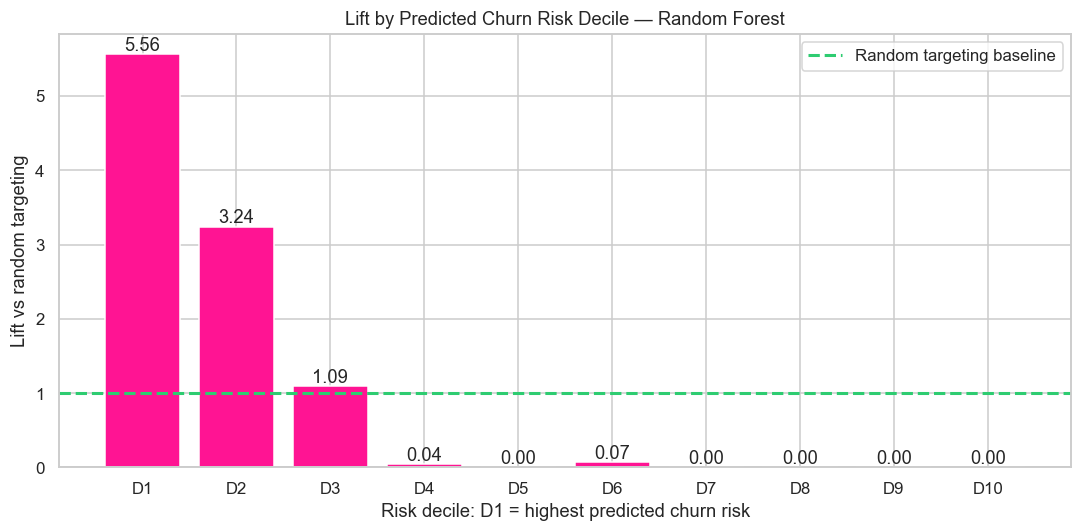

In [54]:
# Visualize lift by predicted risk decile

plt.figure(figsize=(10, 5))

bars = plt.bar(
    lift_summary["Risk_Decile"].astype(str),
    lift_summary["Lift"],
    color="#FF1493"
)

plt.axhline(
    y=1,
    color="#2ECC71",
    linestyle="--",
    linewidth=2,
    label="Random targeting baseline"
)

plt.title("Lift by Predicted Churn Risk Decile — Random Forest")
plt.xlabel("Risk decile: D1 = highest predicted churn risk")
plt.ylabel("Lift vs random targeting")

for bar, value in zip(bars, lift_summary["Lift"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

- The Random Forest model is highly effective at ranking customers by churn risk.
- The test-set baseline churn rate is **16.82%**, meaning that a random group of customers would contain churners at this average rate.
- The highest-risk decile, `D1`, has an actual churn rate of **93.49%** and a lift of **5.56**. This means that customers in the top 10% predicted-risk group are more than **5 times more likely to churn** than a randomly selected customer.
- The second decile, `D2`, also performs strongly, with a churn rate of **54.44%** and a lift of **3.24**.
- After `D2`, the lift drops sharply: `D3` is only slightly above the baseline, while the remaining deciles contain very few churners.
- From a marketing perspective, the company should prioritize `D1` and `D2` for retention campaigns. `D3` could be considered only for lower-cost actions or if the campaign budget allows broader targeting.
- This confirms that the model is not only statistically accurate, but also operationally useful for churn campaign prioritization.

## Task C Summary

Task C developed and evaluated two churn propensity models: Logistic Regression and Random Forest.

The dataset was split into training and testing sets using stratification, preserving the original churn imbalance of around **16.8% churners**. This was important because churners are the minority class.

Logistic Regression provided a strong baseline, with high churn recall (**0.838**), but low churn precision (**0.440**). This means it was able to detect many churners, but also incorrectly flagged many retained customers.

Random Forest performed better overall. It achieved higher accuracy (**0.928**), higher churn recall (**0.873**), much higher churn precision (**0.745**) and a stronger F1-score (**0.804**). The ROC and Precision-Recall curves also confirmed that Random Forest separates and ranks churn-risk customers more effectively.

The confusion matrix showed why recall is critical in churn prediction: a false negative means missing a customer who actually churns, so the company loses the opportunity to intervene. A false positive is less costly because it mainly means contacting a customer who would have stayed anyway.

Finally, the lift analysis showed that Random Forest is operationally useful for campaign targeting. The highest-risk decile had a churn rate of **93.49%** and a lift of **5.56**, while the second decile also showed strong lift. Therefore, the model can help prioritize retention actions on the customers most likely to churn.

Overall, **Random Forest is selected as the preferred churn propensity model** because it combines strong predictive performance with practical value for targeted marketing campaigns.

# Task D — Presentation Deliverable

### Evidence for the presentation

Before preparing the final slides, we collect the key evidence from the model and previous analysis.

In [64]:
# Feature importance from the selected Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = feature_importance.head(10)

display(top_features.round(4))

,Feature,Importance
0,Tenure,0.3011
12,CashbackAmount,0.0849
7,Complain,0.0794
2,WarehouseToHome,0.0582
11,DaySinceLastOrder,0.0562
6,NumberOfAddress,0.0518
5,SatisfactionScore,0.0466
8,OrderAmountHikeFromlastYear,0.0416
21,PreferedOrderCat_Mobile,0.0379
24,MaritalStatus_Single,0.0294


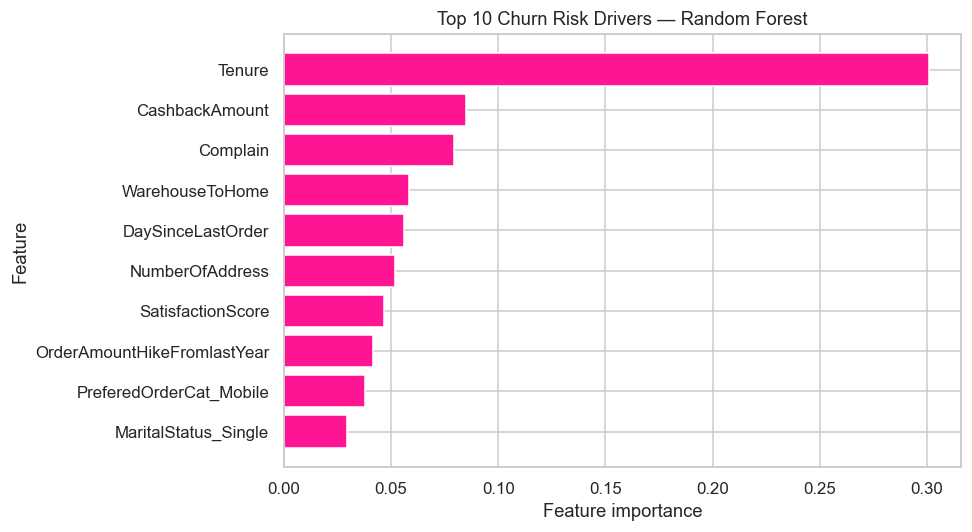

In [65]:
# Visualize top feature importances
plt.figure(figsize=(9, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="#FF1493"
)

plt.title("Top 10 Churn Risk Drivers — Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The Random Forest feature importance highlights the variables that contribute most to churn prediction.

The top churn risk drivers are translated into business terms as follows:

- `Tenure` → **Early lifecycle risk**: customers with shorter tenure are more exposed to churn, as already shown in the EDA.
- `CashbackAmount` → **Incentive sensitivity / value signal**: cashback-related behavior helps the model distinguish customers with different churn risk.
- `Complain` → **Negative customer experience**: customers who complained showed a much higher churn rate than customers without complaints.

These three drivers will form the basis of Slide 1, while the lift results from Task C will support the campaign targeting logic in the final recommendation.